## Speedup and Amdahl's Law

Amdahl's law is the fundamental principle behind estimating the benefit of speeding up any part of a process. It applies whenever some portion of a system is made faster while the rest stays the same &mdash; not only when adding parallel resources.

*Speedup* is the standard way to measure how much faster a process becomes after an improvement.

  * $T_{old}$ = time to complete the process before the improvement
  * $T_{new}$ = time to complete the process after the improvement
  * Speedup $S = T_{old}/T_{new}$

Examples include:

  * adding parallel resources to a computation
  * replacing an algorithm with an asymptotically faster one
  * swapping a hard disk for an SSD
  * caching a slow database query
  * offloading a computation to a GPU

In every case, part of the process gets faster and part doesn't, and Amdahl's law tells us the resulting overall speedup.

### Concepts in this unit
  * Amdahl's law
  * speedup
  * the enhanced fraction of a process
  * speedup estimation

### Outcomes
The ability to apply Amdahl's law in both directions:
  * estimate the overall speedup of a process from the fraction enhanced and the speedup of that fraction
  * estimate the fraction of a process that was enhanced from a measured overall speedup

## Amdahl's Law

Suppose an enhancement speeds up a fraction $f$ of a process by a factor of $k$. The remaining fraction, $(1-f)$, is unaffected. The overall speedup is:

$$S = \frac{1}{(1-f) + \dfrac{f}{k}}$$

* $f$ &mdash; the fraction of the original execution time affected by the enhancement (the "enhanced fraction")
* $(1-f)$ &mdash; the fraction not affected by the enhancement
* $k$ &mdash; the speedup of the enhanced fraction, in isolation
* $S$ &mdash; the overall speedup of the whole process

Paraphrased: overall speedup is capped by how much of the process you actually enhance, no matter how much you enhance it.

Parallelism is one special case of this law, where $k$ is the number of parallel resources applied to the parallelized fraction $f$ of a computation. But the law doesn't care *why* the enhanced fraction got faster &mdash; the same equation governs a faster disk, a better algorithm, or an extra GPU.

### Why the unenhanced fraction dominates

A block diagram makes the asymmetry concrete: split execution time into an enhanced piece and an unenhanced piece, then watch what happens to each piece when the enhanced one gets much faster.

Matplotlib is building the font cache; this may take a moment.


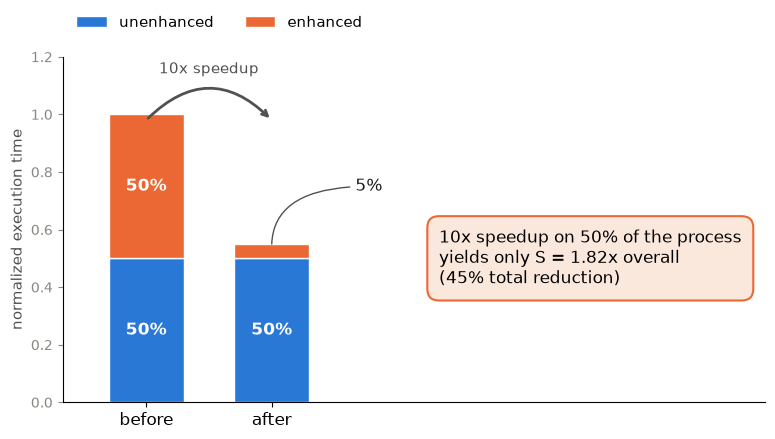

In [1]:
# Claude generated replacement figure 
import matplotlib.pyplot as plt

f = 0.5   # enhanced fraction
k = 10    # speedup of the enhanced fraction

unenhanced = 1 - f
enhanced_before = f
enhanced_after = f / k
after_total = unenhanced + enhanced_after
S = 1 / after_total

blue = '#2a78d6'    # unenhanced portion
orange = '#eb6834'  # enhanced portion

fig, ax = plt.subplots(figsize=(8, 4.5))

bar_width = 0.45
x_before, x_after = 0, 0.75

ax.bar(x_before, unenhanced, bar_width, color=blue, edgecolor='white', linewidth=1, label='unenhanced')
ax.bar(x_before, enhanced_before, bar_width, bottom=unenhanced, color=orange, edgecolor='white', linewidth=1, label='enhanced')

ax.bar(x_after, unenhanced, bar_width, color=blue, edgecolor='white', linewidth=1)
ax.bar(x_after, enhanced_after, bar_width, bottom=unenhanced, color=orange, edgecolor='white', linewidth=1)

ax.text(x_before, unenhanced / 2, f'{unenhanced:.0%}', ha='center', va='center',
        color='white', fontsize=12, fontweight='bold')
ax.text(x_before, unenhanced + enhanced_before / 2, f'{enhanced_before:.0%}', ha='center', va='center',
        color='white', fontsize=12, fontweight='bold')

ax.text(x_after, unenhanced / 2, f'{unenhanced:.0%}', ha='center', va='center',
        color='white', fontsize=12, fontweight='bold')

ax.annotate(f'{enhanced_after:.0%}', xy=(x_after, after_total - 0.01),
            xytext=(x_after + 0.5, after_total + 0.2),
            fontsize=12, ha='left', va='center', color='#1a1a1a',
            arrowprops=dict(arrowstyle='-', connectionstyle='angle3,angleA=0,angleB=90', color='#52514e'))

ax.annotate('', xy=(x_after, unenhanced + enhanced_before - 0.02),
            xytext=(x_before, unenhanced + enhanced_before - 0.02),
            arrowprops=dict(arrowstyle='->', lw=2, color='#52514e',
                             connectionstyle='arc3,rad=-0.5'))
ax.text((x_before + x_after) / 2, 1.13, f'{k}x speedup', ha='center', va='bottom',
        fontsize=11, color='#52514e')

ax.text(1.75, 0.5,
        f"{k}x speedup on {f:.0%} of the process\n"
        f"yields only S = {S:.2f}x overall\n"
        f"({(1 - after_total):.0%} total reduction)",
        fontsize=12, va='center', ha='left',
        bbox=dict(boxstyle='round,pad=0.7', fc='#fbe8dd', ec='#eb6834', linewidth=1.5))

ax.set_xticks([x_before, x_after])
ax.set_xticklabels(['before', 'after'], fontsize=12)
ax.set_ylabel('normalized execution time', fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_xlim(-0.5, 3.7)
ax.legend(loc='upper left', bbox_to_anchor=(0, 1.16), ncol=2, frameon=False, fontsize=11)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.label.set_color('#52514e')

plt.tight_layout()
plt.show()

Even a 10x speedup on half the process barely moves the total &mdash; the unenhanced half is now almost the entire bar. This regenerates the same intuition as Greg Ganger's original 50/50 block figure, but from the $f$/$k$ notation, so you can change the numbers above and rerun it for any enhancement.

### Visualizing Amdahl's Law

Let's look at the Amdahl curve for a given enhanced fraction (.92) as we increase the speedup $k$ applied to it.

In [2]:
import numpy as np
import pandas as pd

k = np.array(range(1,65))
f = 0.92

dfdata = {'k': k, 'speedup': 1/((1-f)+f/k)}
df = pd.DataFrame(dfdata)
df

,k,speedup
0,1,1.000000
1,2,1.851852
2,3,2.586207
3,4,3.225806
4,5,3.787879
...,...,...
59,60,10.489510
60,61,10.517241
61,62,10.544218
62,63,10.570470


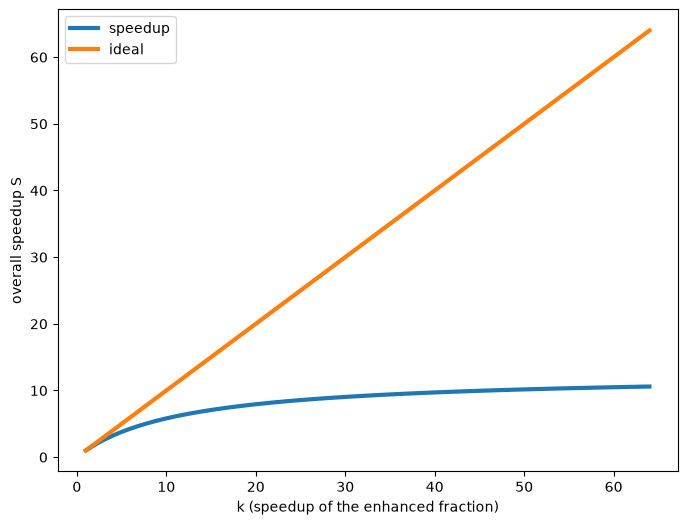

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(df.k, df.speedup, linewidth=3, label='speedup')
plt.plot(df.k, df.k, linewidth=3, label='ideal')
plt.xlabel('k (speedup of the enhanced fraction)')
plt.ylabel('overall speedup S')
plt.legend()
plt.show()

#### Linear (Ideal) Speedup

According to Amdahl's law, the best speedup is achieved when $f=1$.
  * the entire process is enhanced
  * doubling the speedup of the enhanced portion doubles the overall speedup

This is the efficiency limit, and it's often plotted alongside a speedup curve to show the gap caused by the unenhanced portion.

#### Properties of a Speedup Plot

* x-axis should have $k$, the speedup applied to the enhanced portion
* y-axis should be overall speedup $S = T_{old}/T_{new}$
* axes should be linear-linear or log-log (log-log more common)

Let's compare with log-log. Same "shape", different scale.

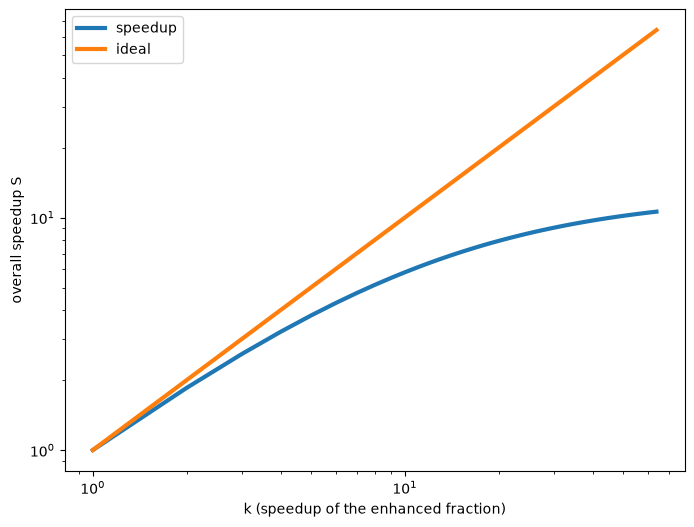

In [4]:
plt.figure(figsize=(8,6))
plt.plot(df.k, df.speedup, linewidth=3, label='speedup')
plt.plot(df.k, df.k, linewidth=3, label='ideal')
plt.xlabel('k (speedup of the enhanced fraction)')
plt.ylabel('overall speedup S')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Scaling

Let's now look at how the overall speedup changes as a function of the enhanced fraction $f$, for increasing $k$. In a parallel program, this might be the number of processor cores used in the solution.

<Axes: >

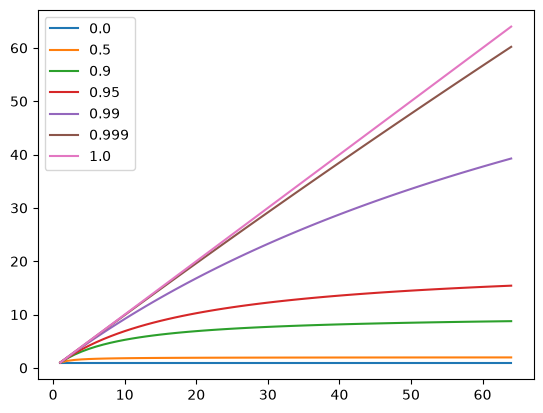

In [6]:
%matplotlib inline

from itertools import product
import numpy as np
import pandas as pd

k_range = range(1,65)
f = [0,.5,.9,.95,.99,.999, 1.0]

data_arr = np.empty((len(k_range), len(f)))

# initialize array using numpy indexing
for i,j in np.ndindex(data_arr.shape):
    data_arr[i,j] = 1/(1-f[j]+f[j]/k_range[i])

df = pd.DataFrame(data=data_arr, index=k_range, columns=f)
df.plot()

### Amdahl's law caps every speedup effort

The graph shows that even a small unenhanced fraction sharply limits the achievable speedup once $k$ grows large. Let's look at this the other way around.

* Suppose you want to achieve a speedup of 80 using an enhancement that is itself 100x faster on the portion it affects (100 parallel processors, a disk 100x faster, whatever the mechanism), what fraction of the original process must be enhanced?

In [7]:
# 80 = 1 / ((1-f)+f/100)
f = (100-100/80)/99
f

0.9974747474747475

So, about $1/4$ of one percent can be left unenhanced. Not much! This is the fundamental limit of any speedup effort, not just parallel ones.

#### So what counts as "unenhanced"?

We call the rest of the process 'unenhanced' as a simple abstraction for whatever doesn't benefit from the improvement.
* Sometimes literal:
  * Code running before/after a parallel region
  * A disk read that isn't sped up when you've only optimized the CPU-bound compute
  * Network latency that a faster algorithm can't touch
* Sometimes metaphorical:
  * When some processing elements sit idle while others do useful work
  * When the enhancement itself introduces additional overhead

The unenhanced fraction is whatever remains slow after the enhancement is applied &mdash; for any kind of speedup process, not only parallel ones.

### Inferring the enhanced fraction from Amdahl's Law

Simplifying a process into 'enhanced' and 'unenhanced' portions lets us infer the enhanced fraction ($f$) from the empirical performance of a process.

In [8]:
# we measure overall speedup as a function of the enhancement's own speedup k
k = np.array([2,4,8,16,32])
speedup = np.array([1.85, 3.30, 5.34, 7.4, 9.4])
f_frac = k/(k-1)*(1-1/speedup)
f_frac

array([0.91891892, 0.92929293, 0.92883895, 0.92252252, 0.92244338])

So, we'd say this process has an enhanced fraction of about .92. This can be converted into a maximum possible speedup.

* Amdahl's law implies that the unenhanced fraction dictates exactly how much speedup is achievable as the enhancement's own speedup grows without bound ($k \to \infty$).

$$S = \frac{1}{(1-f) + \dfrac{f}{k}} \Bigg|_{k \to \infty} = \frac{1}{1-f}$$

In [9]:
slim = 1/(1-0.92)
slim

12.500000000000007

Let's look at this limit on the speedup plot.

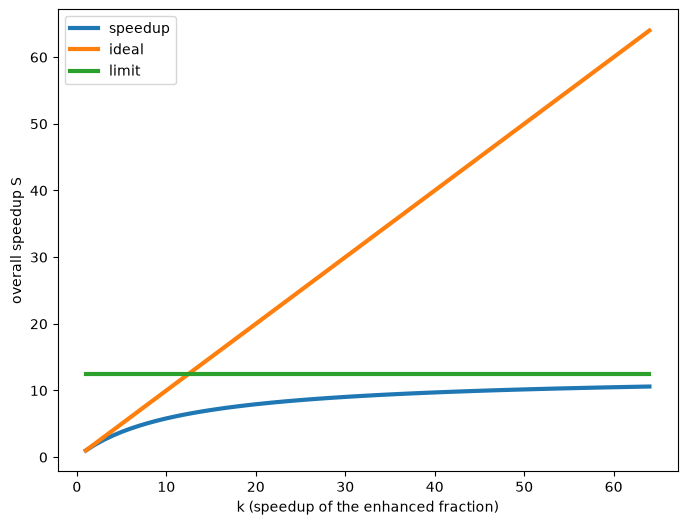

In [10]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

k = np.array(range(1,65))
f = 0.92

dfdata = {'k': k, 'speedup': 1/((1-f)+f/k)}
df = pd.DataFrame(dfdata)

plt.figure(figsize=(8,6))
plt.plot(df.k, df.speedup, linewidth=3, label='speedup')
plt.plot(df.k, df.k, linewidth=3, label='ideal')
plt.plot(df.k, slim + 0*df.k, linewidth=3, label='limit')
plt.xlabel('k (speedup of the enhanced fraction)')
plt.ylabel('overall speedup S')
plt.legend()
plt.show()

_Activity_: Given the fraction of the process that is enhanced and unenhanced for the following code snippet

<code>

    // 2% of serial execution time spent outside of the loop
    ...some computation here...

    // 98% of serial execution time spent in this loop that is parallelized
    #pragma omp parallel for
    for (int i=0; i<N; i++ )
    {
        ...other computation here...
    }
</code>

__draw a speedup chart__, using $f$, $k$, and $S$, that includes
  - 3 points on the Amdahl's law curve (give exact values),
  - the line of ideal speedup that serves as an upper bound for all speedup, and
  - the asymptote for the maximum possible speedup of this code as $k \to \infty$.

This example happens to enhance the code by parallelizing a loop, but nothing about the chart depends on that &mdash; the same three curves would result from replacing that 98% with a 100x faster algorithm.

## Parting Thoughts

Performance in practice is much more complex than splitting a process into an 'enhanced' and 'unenhanced' portion. But Amdahl's law is incredibly useful for:
  * back-of-the-envelope calculations about the limits of any speedup effort (setting a speed limit)
  * deciding what part of a system is worth optimizing

A typical optimization process
  * implement/measure a baseline
  * instrument/profile to determine how much time is spent in what steps
  * enhance only the expensive steps
    * enhancement is often hard work (e.g. writing a correct parallel program is ~10x harder than a serial one)
    * or choose not to enhance a step, because the resulting speedup limit isn't worth the effort

So we use Amdahl's law to:
  * decide whether an enhancement &mdash; parallel or otherwise &mdash; is worth pursuing
  * pick what part of a process to optimize